# Loan Approval Prediction - Exploratory Data Analysis

This notebook performs exploratory data analysis on the loan application dataset. The goal is to understand the feature distributions, identify correlation patterns, detect outliers, and examine class imbalance in the target variable `Approved`.

## Objectives:
1. Load and inspect the dataset (`loan_data.csv`).
2. Generate summary statistics.
3. Check for class imbalance in `Approved`.
4. Detect outliers (specifically looking for anomalous `Age` values and extreme `Income` values).
5. Plot feature distributions and correlation heatmaps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

os.makedirs("plots", exist_ok=True)

## 1. Load the Dataset

In [2]:
df = pd.read_csv("loan_data.csv")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1000, 5)


,Age,Income,LoanAmount,CreditScore,Approved
0,56,31751.94,77243.66,821,0
1,69,51958.75,66247.40,572,0
2,46,58693.51,63394.84,701,0
3,32,115762.93,190497.93,482,0
4,60,75586.67,185442.23,787,0


## 2. General Data Info & Summary Statistics

In [3]:
print("=== Dataset Info ===")
df.info()

print("\n=== Summary Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1000 non-null   int64  
 1   Income       1000 non-null   float64
 2   LoanAmount   1000 non-null   float64
 3   CreditScore  1000 non-null   int64  
 4   Approved     1000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 39.2 KB

=== Summary Statistics ===


,Age,Income,LoanAmount,CreditScore,Approved
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,47.386000,6.591644e+04,103732.911870,580.468000,0.220000
std,17.510672,1.151764e+05,73726.006493,159.778077,0.414454
min,18.000000,1.218160e+04,8951.230000,300.000000,0.000000
25%,33.000000,3.598095e+04,51703.927500,441.000000,0.000000
50%,47.000000,5.064344e+04,85200.305000,577.000000,0.000000
75%,62.000000,7.350142e+04,137767.342500,723.000000,0.000000
max,144.000000,2.300000e+06,500000.000000,850.000000,1.000000


## 3. Class Imbalance Analysis

Let's check the distribution of our target variable `Approved`.

=== Class Distribution ===
Class 0: 780 (78.00%)
Class 1: 220 (22.00%)


/var/folders/8w/l7l5mdb15fdct47_76218l5m0000gn/T/ipykernel_6597/1844766265.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Approved', data=df, palette="viridis")


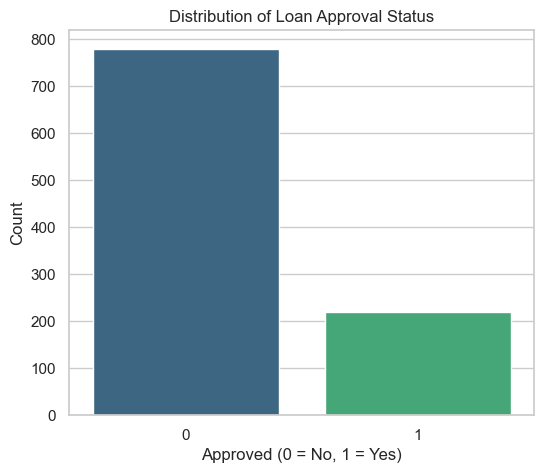

In [4]:
approved_counts = df['Approved'].value_counts()
approved_pct = df['Approved'].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
for val, count in approved_counts.items():
    print(f"Class {val}: {count} ({approved_pct[val]:.2f}%)")

plt.figure(figsize=(6, 5))
sns.countplot(x='Approved', data=df, palette="viridis")
plt.title("Distribution of Loan Approval Status")
plt.xlabel("Approved (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.savefig("plots/target_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Feature Distributions & Outlier Detection

Let's look at the distribution of the features `Age`, `Income`, `LoanAmount`, and `CreditScore` to identify any outliers.

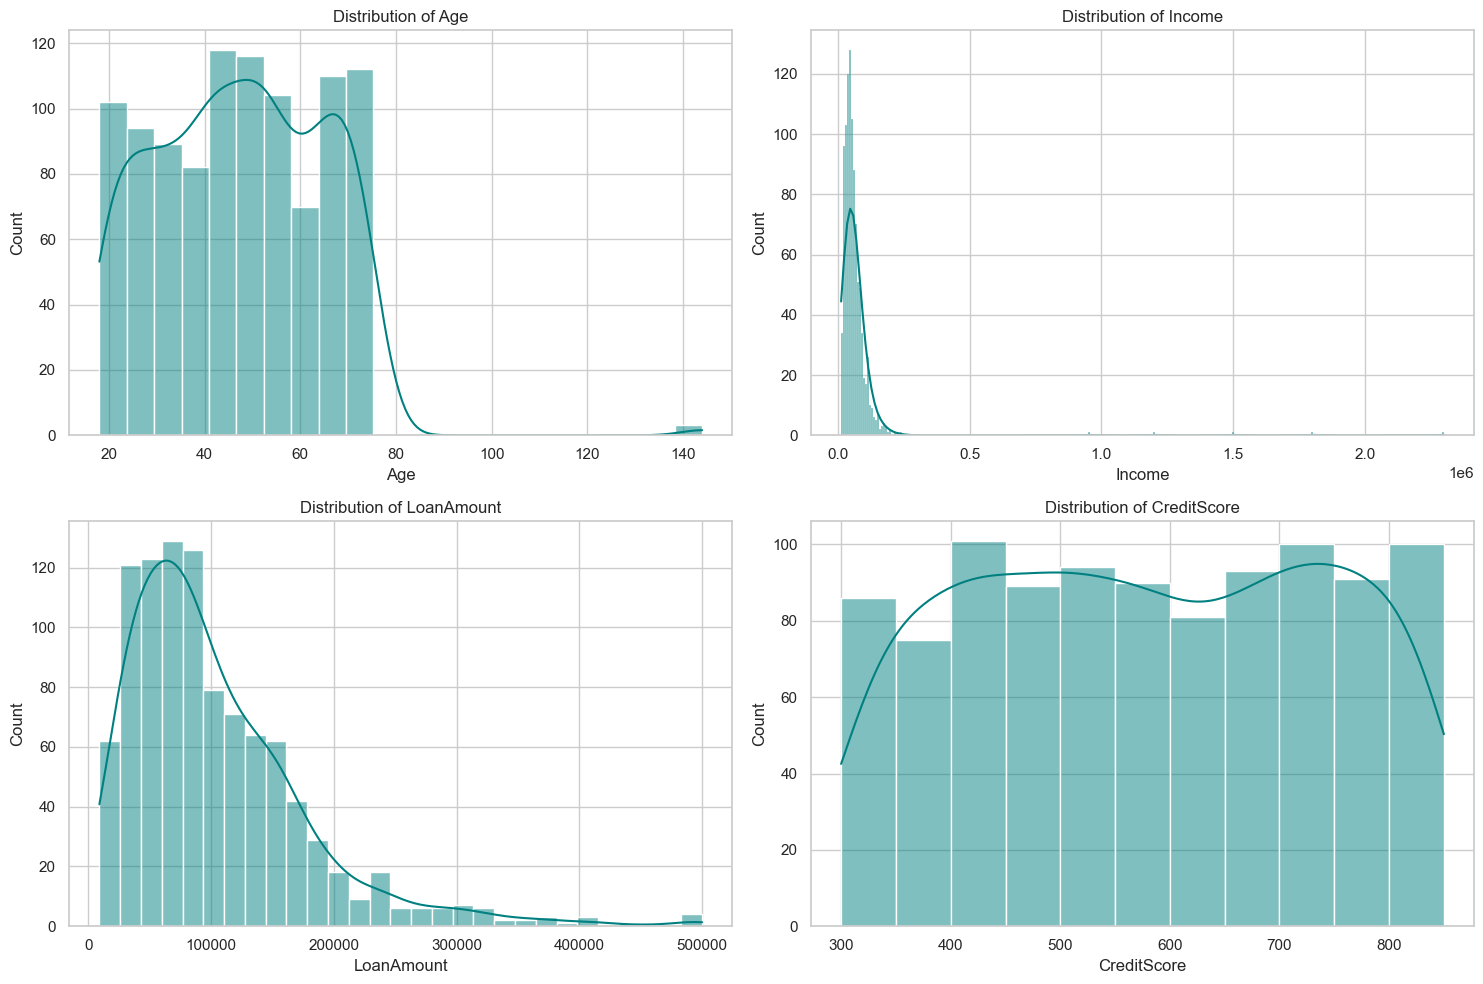

In [5]:
features = ['Age', 'Income', 'LoanAmount', 'CreditScore']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.histplot(df[feat], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {feat}')

plt.tight_layout()
plt.savefig("plots/feature_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

### Boxplots to Highlight Outliers

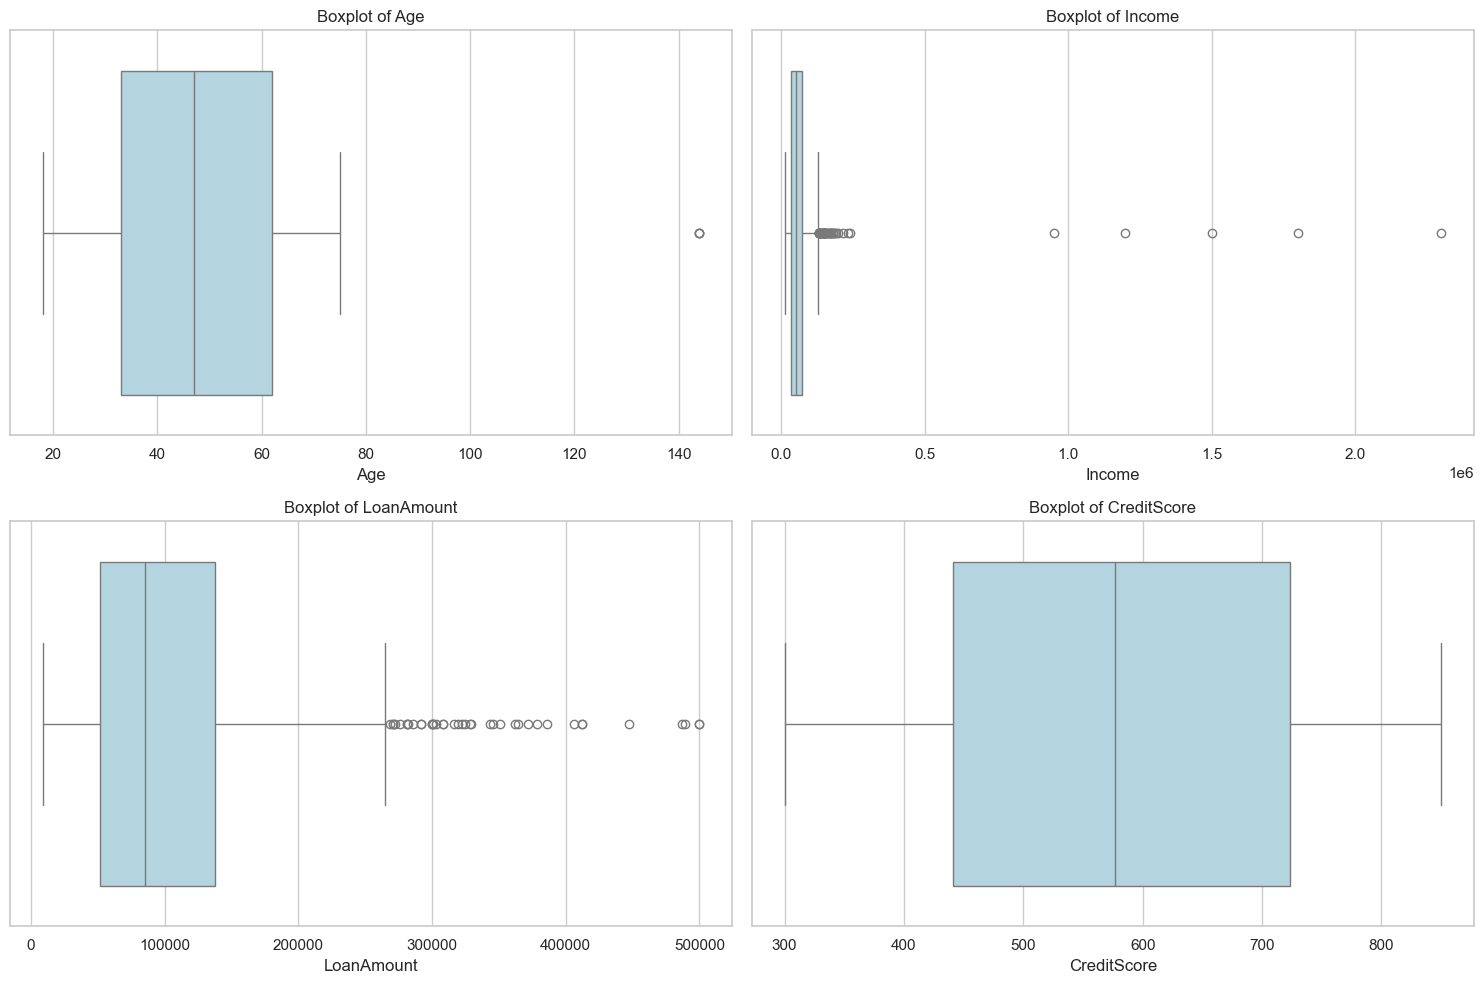

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(x=df[feat], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {feat}')

plt.tight_layout()
plt.savefig("plots/feature_boxplots.png", dpi=300, bbox_inches='tight')
plt.show()

### Inspecting Specific Outliers

1. **Age Outliers**: Let's view rows where `Age > 100`.
2. **Income Outliers**: Let's view extreme values of `Income`.

In [7]:
age_outliers = df[df['Age'] > 100]
print(f"Number of Age outliers (> 100): {len(age_outliers)}")
print(age_outliers)

Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
income_outliers_iqr = df[df['Income'] > (Q3 + 1.5 * IQR)]
print(f"\nNumber of Income outliers (IQR method): {len(income_outliers_iqr)}")
print(income_outliers_iqr.sort_values(by='Income', ascending=False).head(10))

Number of Age outliers (> 100): 3
     Age    Income  LoanAmount  CreditScore  Approved
152  144  19270.37    16484.38          846         1
448  144  77168.56   137414.97          661         0
557  144  30049.96    31931.23          495         0

Number of Income outliers (IQR method): 46
     Age      Income  LoanAmount  CreditScore  Approved
476   53  2300000.00    25548.71          300         1
832   38  1800000.00   232723.63          827         1
924   51  1500000.00    72196.48          389         1
240   75  1200000.00    14712.46          680         1
300   69   950000.00    31889.58          564         1
433   40   238872.65   500000.00          839         0
602   51   231522.82   299882.50          730         1
173   56   217096.77   411930.60          569         0
245   20   198395.21   371795.74          553         0
379   20   193095.31   133542.69          697         1


## 5. Correlation Analysis

Let's see how the numerical features correlate with each other and with the target `Approved`.

=== Correlation Matrix ===
                  Age    Income  LoanAmount  CreditScore  Approved
Age          1.000000  0.003787   -0.054822     0.023910 -0.015023
Income       0.003787  1.000000    0.200118    -0.018913  0.138139
LoanAmount  -0.054822  0.200118    1.000000     0.011304 -0.268988
CreditScore  0.023910 -0.018913    0.011304     1.000000  0.456176
Approved    -0.015023  0.138139   -0.268988     0.456176  1.000000


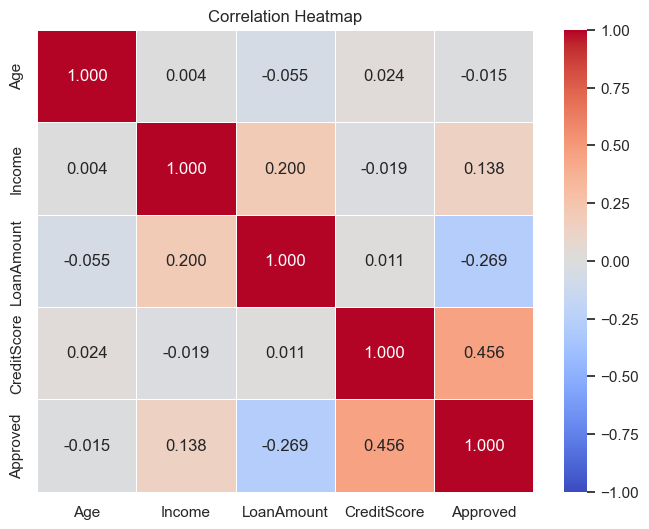

In [8]:
corr_matrix = df.corr()
print("=== Correlation Matrix ===")
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Key EDA Findings & Next Steps

1. **Class Imbalance**: The target `Approved` has a positive class rate of ~22%. We must address this class imbalance during modeling (e.g., using `class_weight='balanced'` in DecisionTree or stratified splitting).
2. **Age Outliers**: There are cases of `Age = 144`, which is physically impossible for a loan applicant. We should cap `Age` at a sensible upper bound (e.g., age 100 or the 99th percentile, say 80).
3. **Income Extremes**: There are extreme incomes (up to $2.3M) which can skew our distance metrics or create split dominance in trees. Capping or applying robust scaling will be key. Let's create a `Debt-to-Income` ratio (`LoanAmount` / `Income`) to provide a normalized feature for the decision tree.
4. **Correlations**: `CreditScore` and `Income` show positive correlations with `Approved`, while `LoanAmount` and `Debt-to-Income` factors are negatively correlated.